In [16]:
import argparse
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'
import pickle
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax.random import PRNGKey
from jax import jit
import jax
import time
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive, autoguide, SVI, Trace_ELBO, TraceMeanField_ELBO
# from numpyro.handlers import mask
import sys
import numpy as np
from typing import NamedTuple
from copy import deepcopy
import tqdm
numpyro.enable_x64(False)
numpyro.set_platform("cpu")
import functools

from dataclasses import dataclass
from typing import Optional
import optax


import jax
import jax.numpy as jnp
import flax.linen as nn
#matplotlib.use("Agg")

In [17]:
def make_mask(params, train_prefixes):
    def mask_fn(param_tree):
        return {k: any((p in k) for p in train_prefixes) for k in param_tree}
    return mask_fn

def chan_norm(x, eps=1e-5):
    # x: (N, C, H)
    m = x.mean(axis=-1, keepdims=True)
    v = jnp.mean((x - m)**2, axis=-1, keepdims=True)
    return (x - m) / jnp.sqrt(v + eps)

In [18]:
def CHO_estimation(x, ra_est):
    # print(x.shape)
    with numpyro.handlers.mask(mask=(ra_est)):
        fan_in = 1 * 7
        std_w  = jnp.sqrt(2.0 / fan_in)
        ch1_kernels = numpyro.sample("ch1_kernels",dist.Normal(loc=jnp.zeros((1,64,7)), scale=std_w))#,rng_key=jax.random.PRNGKey(0)
        ch1_bias = numpyro.sample("ch1_bias",dist.Normal(loc=jnp.zeros((1,64,1)), scale=1E-2))#,rng_key=jax.random.PRNGKey(0)
        fan_in = 64 * 7
        std_w  = jnp.sqrt(2.0 / fan_in)
        ch2_kernels = numpyro.sample("ch2_kernels",dist.Normal(loc=jnp.zeros((64, 16,7)), scale=std_w))
        ch2_bias = numpyro.sample("ch2_bias",dist.Normal(loc=jnp.zeros((1,16,1)), scale=1E-2))
        fan_in = 16 * 96
        std_w  = jnp.sqrt(2.0 / fan_in)
        ch2T_kernels = numpyro.sample("ch2T_kernels",dist.Normal(loc=jnp.zeros((16,16,96)), scale=std_w))
        fan_in = 16 * 7
        std_w  = jnp.sqrt(2.0 / fan_in)
        ch2D_kernels = numpyro.sample("ch2D_kernels",dist.Normal(loc=jnp.zeros((16,64,7)), scale=std_w))
        ch2D_bias = numpyro.sample("ch2D_bias",dist.Normal(loc=jnp.zeros((1,64,1)), scale=1E-2))
        fan_in = 64 * 3
        std_w  = jnp.sqrt(2.0 / fan_in)
        ch1T_kernels = numpyro.sample("ch1T_kernels",dist.Normal(loc=jnp.zeros((64,64,3)), scale=std_w))
        fan_in = 3 * 1
        std_w  = jnp.sqrt(2.0 / fan_in)
        ch1D_kernels = numpyro.sample("ch1D_kernels",dist.Normal(loc=jnp.zeros((64,1,3)), scale=std_w))
        ch1D_bias = numpyro.sample("ch1D_bias",dist.Normal(loc=jnp.zeros((1,1,1)), scale=1E-2))
        out = jax.nn.relu(jax.lax.conv_general_dilated((x[:,None,:]-150.0)/100.0,ch1_kernels,window_strides=[1],padding="SAME",dimension_numbers=("NCH","IOH","NCH"))
                          +ch1_bias)
        outavg = nn.avg_pool(out.transpose(0,2,1),(3,),(3,)).transpose(0,2,1)
        out2 = jax.nn.relu(jax.lax.conv_general_dilated(outavg,ch2_kernels,window_strides=[1],padding="SAME",dimension_numbers=("NCH","IOH","NCH"))
                          +ch2_bias)
        outavg2 = nn.avg_pool(out2.transpose(0,2,1),(out2.shape[-1],),(out2.shape[-1],)).transpose(0,2,1)
        tc2 = jax.lax.conv_transpose(outavg2,ch2T_kernels,strides=[1],padding="VALID",dimension_numbers=("NCH","IOH","NCH"))
        upscaled2 = out2 + tc2
        out2D = jax.nn.relu(jax.lax.conv_general_dilated(upscaled2,ch2D_kernels,window_strides=[1],padding="SAME",dimension_numbers=("NCH","IOH","NCH"))
                           +ch2D_bias)

        tc1 = jax.lax.conv_transpose(out2D,ch1T_kernels,strides=[3],padding="VALID",dimension_numbers=("NCH","IOH","NCH"))
        upscaled1 = out + tc1
        out1D = jax.nn.relu(jax.lax.conv_general_dilated(upscaled1,ch1D_kernels,window_strides=[1],padding="SAME",dimension_numbers=("NCH","IOH","NCH"))
                           +ch1D_bias)
        

    return out1D[:,0,:]


In [19]:
def dz_dt(state, xs, parameters, nn_parameters):
    """
    Diff. Eq. of glycemia.
    State variables:
        SG: Subcutaneous glucose
        G: Blood glucose
        X: Insulin effect
        Ip: Plasma insulin
        S1,2: Subcutaneous insulin 1,2
        E1,2: Energy expenditure 1,2

    Parameters:
        EGP: Endogenous glucose production, varies between days.
        GEZI: Defines glucose steady state at zero plasma insulin.
        SI: Insulin sensitivity, varies during and between days.
        hypo: Increased insulin effect in hypoglycemia.
        ht: Threshold for increased insulin effect in hypoglycemia approx. 60-70 mg/dL.
        EI: Sensitivity of elevated heart rate on energy expenditure.
        Sdelay: Time constant between plasma and subcutaneous glucose.
        ihr: Increased absorption due to elevated heart rate, might be very arbitrary.

    Inputs:
        basal_insulin: Long acting insulin injections are converted to constant infusion rates assuming 24 hours of total action.
        Sa: Short-acting insulin injections in the subcutanous space modeled by the sum of first-order impulse responses.
        Ra: Rate of glucose appearance from meal intakes, modeled by the sum of third-order impulse responses.
        hr: Excess heart rate, measured from 70 BPM resting heart rate.
    """
    SG, X1, Ip, S1, G, S2, E1, E2 = state
    G = jax.nn.softplus(G) # Constraint on G > 0
    SG = jax.nn.softplus(SG) # Constraint on SG > 0
    renal_threshold = jax.nn.softplus(G-9*18.0)

    # Parameters
    EGP, GEZI, SI, tau1, p2, tau2, taup, tau0, hypo, ht, taue, EI, tauG, ihr = parameters
    CI = 1200.0 # Insulin clearance fixed for identifiability
    sampling_time = 5.0

    # Inputs
    basal_insulin, bolus_insulin, Ra, SIt, Sa, EGPt, hr, Pa = xs

    # Differential equations
    dE1dt = (-E1 + hr*EI)/taue
    dE2dt = (-E2 + E1)/taue
    dS1dt = (-S1 + basal_insulin / CI) / tau1
    dS2dt = (-S2 + S1 + Sa) / tau2
    dIpdt = (-Ip + S2) / (taup)
    dX1dt = (-X1 + SIt * Ip)/p2
    dGdt = (- (GEZI+ (1.0+hypo*jnp.heaviside(ht-G,0.0))*(X1)) * G
             + EGPt + Ra - E2/taue - 0.003*renal_threshold)
    dSGdt = (G - SG)/tauG

    next_state = state + sampling_time*jnp.stack((dSGdt,dX1dt,dIpdt,dS1dt,dGdt,dS2dt,dE1dt,dE2dt))

    return next_state, next_state

In [20]:
def Ra(time, meal_info, Vg, tau0):

    carb, start_times, durations, taud = meal_info # 4 by Number of meals

    sampled_start_times = start_times
    sampled_tauds = taud[:,None]
    sampled_carbs = carb[:,None]

    rate_of_appearance_time_array_full = jnp.transpose(jnp.linspace(time[0] - sampled_start_times, time[-1] - sampled_start_times, time.size))
    binmap = jnp.heaviside(rate_of_appearance_time_array_full, 1.0)
    rate_of_appearance_time_array_full = jnp.clip(rate_of_appearance_time_array_full, min=0.0)

    expbt = jnp.exp(jnp.divide(-rate_of_appearance_time_array_full, sampled_tauds))
    expat = jnp.exp(jnp.divide(-rate_of_appearance_time_array_full, tau0 * jnp.ones(sampled_tauds.shape)))

    term1 = jnp.divide(jnp.multiply(expbt, binmap*rate_of_appearance_time_array_full), jnp.abs(tau0 - sampled_tauds)*sampled_tauds)
    term2 = jnp.divide(jnp.multiply(expat, binmap*tau0), jnp.power(tau0 - sampled_tauds, 2))
    term3 = jnp.divide(jnp.multiply(expbt, binmap*tau0), jnp.power(tau0 - sampled_tauds, 2))

    Ra = jnp.sum(jnp.multiply(sampled_carbs, term1 + term2 - term3), 0)

    return Ra

In [21]:
def Sa(time, insulin_info, CI=1200.0):

    bolus, start_times, durations, taud = insulin_info

    sampled_start_times = start_times
    sampled_tauds = taud[:,None]
    sampled_carbs = bolus[:,None]*1E6

    rate_of_appearance_time_array_full = jnp.transpose(
        jnp.linspace(time[0] - sampled_start_times, time[-1] - sampled_start_times, time.size))
    binmap = jnp.heaviside(rate_of_appearance_time_array_full,1.0)
    rate_of_appearance_time_array_full = jnp.clip(rate_of_appearance_time_array_full, min=0.0)

    d_temp = jnp.divide(-rate_of_appearance_time_array_full, sampled_tauds)
    m2_temp = jnp.multiply(sampled_carbs / CI, jnp.divide(jnp.multiply(jnp.exp(d_temp), binmap), sampled_tauds))
    Ra = jnp.sum(m2_temp, 0)

    return Ra

In [22]:
def Pa(time, exercise_info, gain=1.0):

    exercise, start_times, durations, taud = exercise_info

    sampled_start_times = start_times
    sampled_tauds = taud[:,None]
    sampled_exercise = exercise[:,None]

    rate_of_appearance_time_array_full = jnp.transpose(
        jnp.linspace(time[0] - sampled_start_times, time[-1] - sampled_start_times, time.size))
    binmap = jnp.heaviside(rate_of_appearance_time_array_full,1.0)
    rate_of_appearance_time_array_full = jnp.clip(rate_of_appearance_time_array_full, min=0.0)

    d_temp = jnp.divide(-rate_of_appearance_time_array_full, sampled_tauds)
    m2_temp = jnp.multiply(gain*sampled_exercise, jnp.divide(jnp.multiply(jnp.exp(d_temp), binmap), sampled_tauds))
    Ra = jnp.sum(m2_temp, 0)

    return Ra

In [23]:
def kernel(X, Z, var, length, jitter=1E-3):
    k = var * jnp.exp(-0.5 * jnp.square((X[None,:]-Z[:,None])/length))
    k = 0.5 * (k + k.T)
    k += jitter * jnp.eye(X.shape[0])
    return k

In [24]:
class nn_Params(NamedTuple):
    W1: jnp.ndarray
    B1: jnp.ndarray
    W2: jnp.ndarray

In [25]:
def model_cohort(sample_data, cohort_meals, cohort_boluses, all_roll, cohort_pa, batch_idxs, fit_mode=0, y=None):
    """
    """
    all_bg, all_basal, all_bolus, all_ts_grid, all_ts_norm, all_hr = sample_data
    full_shape = jnp.ones((all_bg.shape[0]))

    cho_est = CHO_estimation(all_bg, (fit_mode==1))

    var = 1.0
    length = 50.0
    time_arr = jnp.linspace(0,1435,288)
    k = kernel(time_arr, time_arr, var, length)

    with numpyro.plate("sample_dim",50):
        with numpyro.handlers.mask(mask=(jnp.logical_or(fit_mode==2,fit_mode==3))):
            ra_residual = 0.0*numpyro.sample("Ra_residual",dist.MultivariateNormal(loc=jnp.zeros(time_arr.shape), covariance_matrix=k))

    with numpyro.handlers.mask(mask=(jnp.logical_or(fit_mode==0,fit_mode==3))):
        # Init conditions on the cohort level
        with numpyro.handlers.scale(scale=0.1):
            Ieff0_l3 = numpyro.sample("Ieff0_l3",dist.TruncatedNormal(low=0.0, high=0.2, loc=0.0, scale=2E-3))
            Ip0_l3 = numpyro.sample("Ip0_l3",dist.TruncatedNormal(low=0.0, high=200.0, loc=0.0, scale=400*0.2))
            Isc0_l3 = numpyro.sample("Isc0_l3",dist.TruncatedNormal(low=0.0, high=100.0, loc=0.0, scale=400*0.2))
    
        # Init conditions on the patient level
        Ieff0_l2 = numpyro.sample("Ieff0_l2",dist.TruncatedNormal(low=0.0, high=0.2, loc=Ieff0_l3, scale=2E-3))
        Ip0_l2 = numpyro.sample("Ip0_l2",dist.TruncatedNormal(low=0.0, high=200.0, loc=Ip0_l3, scale=400*0.2))
        Isc0_l2 = numpyro.sample("Isc0_l2",dist.TruncatedNormal(low=0.0, high=100.0, loc=Isc0_l3, scale=400*0.2))
    
        # Init conditions on the sample level
        Ieff0_l2S = numpyro.sample("Ieff0_l2S",dist.HalfNormal(scale=2E-3))
        Ip0_l2S = numpyro.sample("Ip0_l2S",dist.HalfNormal(scale=400*0.2))
        Isc0_l2S = numpyro.sample("Isc0_l2S",dist.HalfNormal( scale=400*0.2))
        Ieff0 = numpyro.sample("Ieff0_l1",dist.TruncatedNormal(low=0.0*full_shape, high=0.2*full_shape, loc=Ieff0_l2*full_shape, scale=Ieff0_l2S*full_shape+1E-5))
        Ip0 = numpyro.sample("Ip0_l1",dist.TruncatedNormal(low=0.0*full_shape, high=200.0*full_shape, loc=Ip0_l2*full_shape, scale=Ip0_l2S*full_shape+1E-5))
        Isc0 = numpyro.sample("Isc0_l1",dist.TruncatedNormal(low=0.0*full_shape, high=100.0*full_shape, loc=Isc0_l2*full_shape, scale=Isc0_l2S*full_shape+1E-5))
    
        z_init = jnp.stack([all_bg[:,0],Ieff0,Ip0,jnp.zeros(Ip0.shape),all_bg[:,0],Isc0,jnp.zeros(Ip0.shape),jnp.zeros(Ip0.shape)],axis=-1)
    
        # Lower and upper bounds for node C
        # EGP, GEZI, SI, tau1, p2, tau2, taup, tau0 ,hypo, ht, taue ,EI, tauG, ihr
        mp_low = jnp.array([0.25,1E-3,2.5E-5,5.0,20.0,20.0,20.0,1.0,0.0,50.0,10.0,0.0,5.0,25.0])
        mp_high = jnp.array([2.5,3E-3,80E-5,80.0,80.0,80.0,80.0,10.0,1.0,100.0,40.0,2.0,30.0,300.0])
    
        # Glucose distribution volume on the patient level
        VG = numpyro.sample("VG",dist.TruncatedNormal(low=40.0, high=300.0, loc=120.0, scale=100.0))
    
        # Node C
        param_prior = 0.5*jnp.ones(mp_low.shape)
        param_prior = param_prior.at[2].set(0.25)
        with numpyro.handlers.scale(scale=0.1):
            model_parameters_l3 = numpyro.sample("model_parameters_l3",
                                       dist.TruncatedNormal(low=jnp.zeros(mp_low.shape),
                                                            high=jnp.ones(mp_low.shape),
                                                            loc=param_prior,
                                                            scale=0.4*jnp.ones(mp_low.shape)))
    
        # Node CP
        model_parameters_l2 = numpyro.sample("model_parameters_l2",
            dist.TruncatedNormal(
                low=jnp.zeros((mp_low.shape[0])),
                high=jnp.ones((mp_low.shape[0])),
                loc=model_parameters_l3,
                scale=0.2*jnp.ones((mp_low.shape[0]))))
        model_parameters = mp_low + (mp_high-mp_low)*model_parameters_l2
    
    
        time_range = jnp.linspace(0,1,288,endpoint=False)
        # Intraday insulin variability on the cohort level
        with numpyro.handlers.scale(scale=0.1):
            phase3 = numpyro.sample("SIp_l3",dist.Uniform(low=-1.0,high=1.0))
            amp3 = numpyro.sample("SIA_l3",dist.TruncatedNormal(loc=0.5,scale=1.0,low=0.0,high=1.0))
        # Intraday insulin variability on the cohort level
        phase2 = numpyro.sample("SIp_l2",dist.TruncatedNormal(low=-1.0,high=1.0,loc=phase3,scale=0.5))
        amp2 = numpyro.sample("SIA_l2",dist.TruncatedNormal(low=0.0,high=1.0,loc=amp3,scale=0.5))
        # Standard deviation on the sample level
        EGPsS = numpyro.sample("EGPsS",dist.Exponential(rate=(1.0/(0.01))))
        SIsS = numpyro.sample("SIsS",dist.Exponential(rate=(1.0/(0.01))))
        phaseS = numpyro.sample("SIpS",dist.Exponential(rate=1.0/0.15))
        ampS = numpyro.sample("SIAS",dist.Exponential(rate=1.0/0.25))
    
    
        EGPsRi = model_parameters_l2[0] # Intercept of the normalized EGP on the patient level
        # Normalized insulin sensitivity on the sample level
        SIsRu = numpyro.sample("SIsR",dist.TruncatedNormal(low=0.0*full_shape, high=1.0*full_shape, loc=full_shape*model_parameters_l2[2], scale=full_shape*SIsS*model_parameters_l2[2]+1E-5))
        # Scaled insulin sensitivity on the sample level
        SIs = numpyro.deterministic("SIs",mp_low[2] + (mp_high[2]-mp_low[2])*SIsRu)
    
        # Correlation between SI and EGP, slope between 0 and 1
        SI_EGP = numpyro.sample("SI_EGP",dist.TruncatedNormal(low=0.0, high=1.0, loc=0.1, scale=1.0))
        EGPsRu = EGPsRi + SI_EGP*SIsRu
        EGPex = mp_low[0] + (mp_high[0]-mp_low[0])*EGPsRu
        # Scaled EGP on sample level
        EGPs = numpyro.sample("EGPs",dist.TruncatedNormal(low=0.25*full_shape, high=2*2.5*full_shape, loc=EGPex, scale=EGPsS*EGPex+1E-5))
        #print(EGPs.shape)
    
        # Intraday insulin variability on the sample level
        phase = numpyro.sample("SIp_l1",dist.TruncatedNormal(low=-1.0*full_shape,high=1.0*full_shape,loc=phase2*full_shape,scale=phaseS*full_shape+1E-5))
        amp = numpyro.sample("SIA_l1",dist.TruncatedNormal(low=0.0*full_shape,high=1.0*full_shape,loc=amp2*full_shape,scale=ampS*full_shape+1E-5))
    
        # Sinusoidal intraday insulin sensitivity variation on the sample level
        SIintra = numpyro.deterministic("SIintra",amp[:,None]*jnp.sin(2*jnp.pi*(time_range[None,:]+phase[:,None])))
        # Time varying insulin sensitivity on the sample level, adjusted for the starting time of the current sample
        #print(SIintra.shape)
        SIt =  numpyro.deterministic("SIt",jnp.roll(SIs[:,None]*(1.0+0.25*SIintra),-all_roll,1))
        EGPt = EGPs[:,None]*jnp.ones(SIt.shape)
    
        # Meal absorption time constant on the patient level
        with numpyro.handlers.mask(mask=(jnp.logical_or(fit_mode==0,fit_mode==3))):
            with numpyro.handlers.scale(scale=0.1):
                tauds_prior = numpyro.sample(name="taud_m_prior", fn=dist.TruncatedNormal(low=11.0,high=90.0,loc=35.0,scale=30.0))
                taudsS = numpyro.sample(name="taud_mS", fn=dist.Exponential(rate=1.0/25.0))
    
        meal_shape = jnp.ones((cohort_meals.shape[0]))
        # Excluding padded zero meals from the likelihood calculation
        with numpyro.handlers.mask(mask=jnp.logical_and(jnp.logical_or(fit_mode==0,fit_mode==3),cohort_meals[:,1]>0)):
            # Offset of meal start time on the meal level
            start_offset = numpyro.sample(name="start_m", fn=dist.TruncatedNormal(low=-90.0*meal_shape,high=90.0*meal_shape,loc=10.0*meal_shape,scale=15.0*meal_shape))
            # Meal absorption time constant on the meal level
            tauds = numpyro.sample(name="taud_m", fn=dist.TruncatedNormal(low=11.0*meal_shape,high=90.0*meal_shape,loc=tauds_prior*meal_shape,scale=taudsS*meal_shape+1E-5))
            # Carb content coefficient on the meal level
            meal_coeff = numpyro.sample(name="meal_coeff", fn=dist.TruncatedNormal(low=0.0*meal_shape,high=3.0*meal_shape,loc=1.0*meal_shape,scale=0.2*meal_shape))
    
    
        meal_info = jnp.asarray([cohort_meals[:,1]*meal_coeff,
                                 cohort_meals[:,0]+start_offset,20.0*jnp.ones_like(cohort_meals[:,0]),tauds]).transpose(0,1)
        # Calculates rate of appearance as 3rd order impulse response
        ra_arr = jax.vmap(Ra,(0,None,None,None))(all_ts_grid,meal_info,1.0,model_parameters.at[7].get())#
        
        # Insulin absorption time constant 1 on the patient level
        taudbi_shape = jnp.ones((cohort_boluses.shape[0]))
        with numpyro.handlers.scale(scale=0.1):
            taudbiS = numpyro.sample(name="taud_biS", fn=dist.HalfNormal(scale=15.0))
        # Excluding padded zero boluses from the likelihood calculation
        with numpyro.handlers.mask(mask=jnp.logical_and(jnp.logical_or(fit_mode==0,fit_mode==3),cohort_boluses[:,1]>0)):
            # Offset of bolus start time on the bolus level
            start_offset_b = numpyro.sample(name="start_b", fn=dist.TruncatedNormal(low=-45.0*taudbi_shape,high=45.0*taudbi_shape, loc=0*taudbi_shape,scale=5*taudbi_shape))
            # Insulin absorption time constant on the bolus level
            taudbi = numpyro.sample(name="taud_bi", fn=dist.TruncatedNormal(low=5.0*taudbi_shape,high=80.0*taudbi_shape,loc=model_parameters[3]*taudbi_shape,scale=taudbiS*taudbi_shape+1E-5))
            # Injection amount coefficient on the bolus level
            bolus_coeff = numpyro.sample(name="bolus_coeff", fn=dist.TruncatedNormal(low=0.75*taudbi_shape,high=1.5*taudbi_shape,loc=1.0*taudbi_shape,scale=0.025*taudbi_shape))
    
    
        insulin_info = jnp.asarray([cohort_boluses[:,1]*bolus_coeff,cohort_boluses[:,0]+start_offset_b,20.0*jnp.ones_like(cohort_boluses[:,1]),taudbi]).transpose(0,1)#theta.at[3].get()*jnp.ones_like(all_boluses[:,1])
        # Calculates insulin appearance in the subcutaneous compartment 2 as a 1st order impulse response
        sa_arr = jax.vmap(Sa,(0,None))(all_ts_grid,insulin_info)
    
        tudpa_shape = jnp.ones((cohort_pa.shape[0]))
    
        # Time constant of the effect of physical activity on the patient level
        with numpyro.handlers.scale(scale=0.1):
            taudpa_prior = numpyro.sample(name="taudpa_prior", fn=dist.TruncatedNormal(low=120.0,high=2500.0,loc=600.0,scale=1000.0))
            taudpaS = numpyro.sample("taudpaS",dist.Exponential(rate=1.0/1000.0))
    
        # Exlcuding padded zero physical activity events from the likelihood calculation
        with numpyro.handlers.mask(mask=jnp.logical_and(jnp.logical_or(fit_mode==0,fit_mode==3),cohort_pa[:,1]>0)):
            # Offset in the start time of the self-reported physical activity
            start_offset_pa = numpyro.sample(name="start_pa", fn=dist.TruncatedNormal(low=-60.0*tudpa_shape,high=60.0*tudpa_shape,loc=0.0*tudpa_shape,scale=15.0*tudpa_shape))
            # Time constants for the short and long effect of physical activity on the event level
            taudpa = numpyro.sample(name="taudpa", fn=dist.TruncatedNormal(low=30.0*tudpa_shape,high=2500.0*tudpa_shape,loc=taudpa_prior*tudpa_shape,scale=taudpaS*tudpa_shape+1E-5))
            taudpa_short = numpyro.sample(name="taudpa_short", fn=dist.TruncatedNormal(low=5.0*tudpa_shape,high=120.0*tudpa_shape,loc=30.0*tudpa_shape,scale=120.0*tudpa_shape))
            # Gain for the short and long effect of physical activity on the event level
            pa_coeff = numpyro.sample(name="pa_coeff", fn=dist.TruncatedNormal(low=0.0*tudpa_shape,high=2500.0*tudpa_shape,loc=taudpa/5.0,scale=taudpa/5.0+1E-5))
            pa_coeff_short = numpyro.sample(name="pa_coeff_short", fn=dist.TruncatedNormal(low=-120.0*tudpa_shape,high=120.0*tudpa_shape,loc=1.0,scale=taudpa_short/5.0+1E-5))
        # Calculates the effect of physical activity as a 1st order impulse response
        pa_info = jnp.asarray([cohort_pa[:,1]*pa_coeff,cohort_pa[:,0]+start_offset_pa,20.0*jnp.ones_like(cohort_pa[:,1]),taudpa]).transpose(0,1)
        pa_arr = jax.vmap(Pa,(0,None))(all_ts_grid,pa_info)
        pa_info = jnp.asarray([cohort_pa[:,1]*pa_coeff_short,cohort_pa[:,0]+start_offset_pa,20.0*jnp.ones_like(cohort_pa[:,1]),taudpa_short]).transpose(0,1)
        pa_arr_short = jax.vmap(Pa,(0,None))(all_ts_grid,pa_info)
        # Physical activity mediated insulin sensitivity
        SItPA = jax.nn.softplus(100.0*(1.0+pa_arr+pa_arr_short))/100.0*SIt
    
        inputs = jnp.stack((all_basal,all_bolus,ra_arr/VG*1000.0,SItPA,sa_arr, EGPt, jax.nn.softplus(all_hr-70.0), pa_arr+pa_arr_short)).transpose(1,2,0)

        # Vectorized numerical integration using 1st order Euler with a sampling time of 5 minutes
        _,states = jax.vmap(lambda z_initp, inputsp, paramp: jax.lax.scan(jax.tree_util.Partial(dz_dt, parameters=paramp, nn_parameters=None),z_initp, inputsp),(0,0,None))(z_init, inputs,model_parameters)
        # Subcutenous glucose concentration
        glucose = states[:,:,0]

    # Simulate glucose trajectory with estimated Ra
    estimated_ra = numpyro.deterministic("Ra_post_est",jax.nn.softplus(100*(cho_est + ra_residual))/100.0)
    inputs_unannounced = jnp.stack((all_basal,all_bolus,estimated_ra/VG*1000.0,SItPA,sa_arr, EGPt, jax.nn.softplus(all_hr-70.0), pa_arr+pa_arr_short)).transpose(1,2,0)        
    _,states_unannounced = jax.vmap(lambda z_initp, inputsp, paramp: jax.lax.scan(jax.tree_util.Partial(dz_dt, parameters=paramp, nn_parameters=None),z_initp, inputsp),(0,0,None))(z_init, inputs_unannounced,model_parameters)
    ra_detached = numpyro.deterministic("ra_detached", jax.lax.stop_gradient(ra_arr))
    if y is None:
        numpyro.deterministic("y_pred", glucose)
        numpyro.deterministic("SIt_pred", SIt)
        numpyro.deterministic("Ra_pred", ra_arr)
        numpyro.deterministic("Sa_pred", sa_arr)
        numpyro.deterministic("Pa_pred", pa_arr+pa_arr_short)
        numpyro.deterministic("Ieff_pred",states[:,:,1])
        numpyro.deterministic("E2_pred",states[:,:,7])
        numpyro.deterministic("Ra_est",cho_est)
        numpyro.deterministic("y_unannounced",states_unannounced[:,:,0])

    else:
        # Measurement noise on the sample level
        with numpyro.handlers.mask(mask=jnp.logical_or(fit_mode==0,fit_mode==3)):
            sigma = numpyro.sample('sigma_i', dist.LogNormal(3.3*full_shape,0.5*full_shape))
        with numpyro.handlers.mask(mask=(fit_mode==0)):
            numpyro.sample("y", dist.Normal(glucose.reshape(-1,glucose.shape[-1]), sigma.reshape((sigma.shape[0],1))+1E-5), obs=all_bg.reshape(-1,all_bg.shape[-1]))#
        with numpyro.handlers.mask(mask=(fit_mode==1)):
            numpyro.sample("ra_est_site", dist.Normal(cho_est, 0.1), obs=ra_detached)#
        with numpyro.handlers.mask(mask=(jnp.logical_or(fit_mode==2,fit_mode==3))):
            numpyro.sample("y_announced", dist.Normal(states_unannounced[:,:,0], sigma[:,None]), obs=all_bg)#


    return

In [26]:
with open("dataset.pkl","rb") as f:
  dataset = pickle.load(f)

In [29]:
fit_mode = 0
MODE = {"phys": 0, "ra_est": 1, "ra_res" : 2, "phys_res": 3}

min_loss = np.inf
save_loss = np.inf

num_epochs = 1000
num_patients = 10
batch = 50
losses = []
patience = 30

svi_states = []

optimizer = numpyro.optim.optax_to_numpyro(optax.adam(1e-3))

guide = autoguide.AutoGuideList(model_cohort)
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(
    autoguide.AutoMultivariateNormal(
        numpyro.handlers.block(model_cohort, expose=["Ieff0_l3","Ip0_l3","Isc0_l3","model_parameters_l3",
                                              "SIp_l3","SIA_l3","taud_m_prior","taud_mS","taud_biS","taudpa_prior","taudpaS"]), prefix="l3_"
    ))
)
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(
    autoguide.AutoMultivariateNormal(
        numpyro.handlers.block(model_cohort, expose=["Ieff0_l2","Ip0_l2","Isc0_l2","Ieff0_l2S","Ip0_l2S","Isc0_l2S","VG","model_parameters_l2",
                                              "SIp_l2","SIA_l2","SI_EGP","EGPsS","SIsS","SIpS","SIAS"]), prefix="l2_"
    ))
)

guide.append(
    numpyro.handlers.mask(mask=(fit_mode == MODE["ra_est"]))(autoguide.AutoDelta(
        numpyro.handlers.block(model_cohort, expose=["ch1_kernels","ch1T_kernels","ch1D_kernels","ch2_kernels","ch2D_kernels",
                                             "ch2T_kernels","ch1_bias","ch2_bias","ch1D_bias","ch2D_bias"]), prefix="unannounced_"
    ))
)
guide.append(
    numpyro.handlers.mask(mask=(fit_mode == MODE["ra_res"] or fit_mode == MODE["phys_res"]))(autoguide.AutoDelta(
        numpyro.handlers.block(model_cohort, expose=["Ra_residual","sample_dim"]), prefix="residual_", init_loc_fn=numpyro.infer.initialization.init_to_median
    ))
)
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["Ieff0_l1"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["Ip0_l1"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["Isc0_l1"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["SIp_l1"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["SIA_l1"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["SIsR"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["EGPs"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["start_b"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["start_m"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["taud_m"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["meal_coeff"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["taud_bi"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["bolus_coeff"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["start_pa"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["taudpa"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["taudpa_short"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["pa_coeff"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["pa_coeff_short"]), prefix="l1_")))
guide.append(numpyro.handlers.mask(mask=(fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]))(autoguide.AutoNormal(numpyro.handlers.block(model_cohort, expose=["sigma_i"]), prefix="l1_")))   
svi = SVI(model_cohort, guide, optimizer, loss=Trace_ELBO(15))
#numpyro.enable_validation(False)

In [ ]:
num_epochs = 100
optimizers = []
init_states = False

svi_states = [0]*10
loaded_params = [0]*10

for patidx in range(num_patients,):
    ridxs = list(range(0, dataset["samples"].shape[2]))
    
    ridxs = ridxs[:batch]
    pidxs = [patidx]*batch
    batch_idxs = jnp.stack((jnp.array(pidxs),jnp.array(ridxs)),axis=1)
    batch_samples = dataset["samples"][:,batch_idxs[:,0],batch_idxs[:,1],:]
    batch_meals = dataset["meals"][batch_idxs[0,0],:,:]
    batch_boluses = dataset["boluses"][batch_idxs[0,0],:,:]
    batch_exercises = dataset["exercises"][batch_idxs[0,0],:,:]
    batch_sample_times = dataset["sample_times"][batch_idxs[0,0],:]
    svi_state = svi.init(PRNGKey(1),sample_data=batch_samples,
                         cohort_meals=batch_meals, cohort_boluses=batch_boluses,
                         all_roll=batch_sample_times,cohort_pa=batch_exercises,batch_idxs=batch_idxs,fit_mode=fit_mode,
                         y=True)
    svi_states[patidx]=svi_state
    params = svi.get_params(svi_states[patidx]).copy()
    if fit_mode == MODE["phys"]:
        guide_mask = make_mask(params, ["l3","l2","l1"])
        freezed_optax = optax.transforms.selective_transform(optax.adam(1e-3), freeze_mask=make_mask(params, ["residual","unannounced"]))
        freezed_optax1 = optax.chain(optax.adam(1e-3), optax.transforms.freeze(make_mask(params, ["residual","unannounced"])))
    if fit_mode == MODE["ra_est"]:
        guide_mask = make_mask(params, ["unannounced"])
        freezed_optax = optax.transforms.selective_transform(optax.adam(1e-3), freeze_mask=make_mask(params, ["residual","l3","l2","l1"]))
        freezed_optax1 = optax.chain(optax.adam(1e-3), optax.transforms.freeze(make_mask(params, ["residual","l3","l2","l1"])))
    if fit_mode == MODE["ra_res"]:
        guide_mask = make_mask(params, ["residual"])
        freezed_optax = optax.transforms.selective_transform(optax.adam(1e-3), freeze_mask=make_mask(params, ["unannounced","l3","l2","l1"]))
        freezed_optax1 = optax.chain(optax.adam(1e-3), optax.transforms.freeze(make_mask(params, ["unannounced","l3","l2","l1"])))
    if  fit_mode == MODE["phys_res"]:
        freezed_optax1 = optax.chain(optax.adam(1e-3), optax.transforms.freeze(make_mask(params, ["unannounced"])))
    masked_optax = optax.masked(optax.adam(1e-3), guide_mask, mask_compatible_extra_args = True)
    
    optimizer = numpyro.optim.optax_to_numpyro(freezed_optax1)
    svi = SVI(model_cohort, guide, optimizer, loss=Trace_ELBO(15))
    if init_states:
        svi_state = svi.init(PRNGKey(1), sample_data=batch_samples,
                             cohort_meals=batch_meals, cohort_boluses=batch_boluses,
                             all_roll=batch_sample_times,cohort_pa=batch_exercises,batch_idxs=batch_idxs,fit_mode=fit_mode,
                             y=True)
    else:
        svi_state = svi.init(PRNGKey(1),sample_data=batch_samples,
                     cohort_meals=batch_meals, cohort_boluses=batch_boluses,
                     all_roll=batch_sample_times,cohort_pa=batch_exercises,batch_idxs=batch_idxs,fit_mode=fit_mode,
                     y=True)
        loaded_params[patidx] = svi.get_params(loaded_states[patidx]).copy()
        filter_phys = loaded_params[patidx].copy()
        if fit_mode == MODE["ra_est"]:
            for key, value in loaded_params[patidx].items():
                if "unannounced" in key:
                    filter_phys.pop(key)
        if fit_mode == MODE["ra_res"]:
            for key, value in loaded_params[patidx].items():
                if "residual" in key:
                    filter_phys.pop(key)
        if fit_mode == MODE["phys_res"]:
            for key, value in loaded_params[patidx].items():
                if "unannounced" not in key:
                    filter_phys.pop(key)
        svi_state = svi.init(PRNGKey(1), init_params = filter_phys, sample_data=batch_samples,
                             cohort_meals=batch_meals, cohort_boluses=batch_boluses,
                             all_roll=batch_sample_times,cohort_pa=batch_exercises,batch_idxs=batch_idxs,fit_mode=fit_mode,
                             y=True)
    svi_states[patidx]=svi_state # Storing new optimizer in the state
    optimizers.append(optimizer)

def body_fn(svi_state,batch_samples,batch_meals,batch_boluses,batch_sample_times,batch_exercises,batch_idxs,fit_mode):
    svi_state, loss = svi.update(svi_state,batch_samples,batch_meals,batch_boluses,batch_sample_times,batch_exercises,batch_idxs,fit_mode, True)
    return svi_state, loss

print("SVI states initialized")
global_loc = None
global_cov = None
global_scale = None

best_elbo = np.inf
best_state = None

with tqdm.trange(1, num_epochs + 1) as t:
    for i in t:
        loss_it = []
        for patidx in range(num_patients,):
            print(patidx)
            ridxs = list(range(0, dataset["samples"].shape[2]))
            ridxs = ridxs[:batch]
            pidxs = [patidx]*batch
            batch_idxs = jnp.stack((jnp.array(pidxs),jnp.array(ridxs)),axis=1)
            batch_samples = dataset["samples"][:,batch_idxs[:,0],batch_idxs[:,1],:]
            batch_meals = dataset["meals"][batch_idxs[0,0],:,:]
            batch_boluses = dataset["boluses"][batch_idxs[0,0],:,:]
            batch_exercises = dataset["exercises"][batch_idxs[0,0],:,:]
            batch_sample_times = dataset["sample_times"][batch_idxs[0,0],:]

            if i>1:
                all_params = svi.get_params(svi_state).copy()
                params_re = svi.get_params(svi_states[patidx]).copy()
                if fit_mode == MODE["ra_est"]:
                    for key, value in all_params.items():
                        if "unannounced" in key:
                            params_re[key] = all_params[key]
                if fit_mode == MODE["phys"] or fit_mode == MODE["phys_res"]:
                    for key, value in all_params.items():
                        if "l3" in key:
                            params_re[key] = all_params[key]

                svi_state = svi.init(PRNGKey(1), init_params = params_re, sample_data=batch_samples,
                         cohort_meals=batch_meals, cohort_boluses=batch_boluses,
                         all_roll=batch_sample_times,cohort_pa=batch_exercises,batch_idxs=batch_idxs,fit_mode=fit_mode,
                         y=True)
                svi_states[patidx] = svi_state
            for bi in range(200,):
                svi_state, loss = jit(body_fn)(svi_states[patidx],batch_samples,batch_meals,batch_boluses,batch_sample_times,batch_exercises,batch_idxs,fit_mode)

                svi_states[patidx] = svi_state
            params_after = svi.get_params(svi_state).copy()

            loss_it.append(jax.device_get(loss))
            print(loss_it[-1])
        losses.append(loss_it)
        if np.mean(losses[-1])<best_elbo:
            best_state = svi_states
            best_elbo = np.mean(losses[-1])
        if i>1:
            t.set_postfix_str(
            "init loss: {:.4f}, avg. loss: {:.4f}".format(
                np.mean(losses[-2]), np.mean(losses[-1])
            ),
            refresh=False,
            )

In [ ]:
with open("batch_svi/svi_20250903_phys_ra_res.pkl","rb") as f:
    loaded_states = pickle.load(f)

In [31]:
svi_states = loaded_states

In [32]:
patidx=0
fit_mode=0
ridxs = list(range(0, dataset["samples"].shape[2]))
ridxs = ridxs[:batch]
pidxs = [patidx]*batch
batch_idxs = jnp.stack((jnp.array(pidxs),jnp.array(ridxs)),axis=1)
batch_samples = dataset["samples"][:,batch_idxs[:,0],batch_idxs[:,1],:]
batch_meals = dataset["meals"][batch_idxs[0,0],:,:]
batch_boluses = dataset["boluses"][batch_idxs[0,0],:,:]
batch_exercises = dataset["exercises"][batch_idxs[0,0],:,:]
batch_sample_times = dataset["sample_times"][batch_idxs[0,0],:]

In [ ]:
#with jax.checking_leaks():
wu = numpyro.handlers.seed(guide,1)(batch_samples,
                        batch_meals, batch_boluses,
                        batch_sample_times,batch_exercises,None,fit_mode,
                        True)  # warm up the guide

In [41]:
with open("saved_model/guide_params_PHYS_RAEST.pkl","rb") as f:
    svi_all_params_load = pickle.load(f)

In [42]:
cohort_predictions = []
cohort_posteriors = []
#fit_mode = 0
full_extract = []
extract = {}
extract["si"] = []
extract["egp"] = []
extract["bg"] = []
extract["ra"] = []
extract["vg"] = []
svi_all_params = []
for patidx in range(num_patients,):
    print(patidx)
    
    svi_patient_params = svi_all_params_load[patidx]
    batch_samples = dataset["samples"][:,patidx,:,:]
    batch_meals = dataset["meals"][patidx,:,:]
    batch_boluses = dataset["boluses"][patidx,:,:]
    batch_exercises = dataset["exercises"][patidx,:,:]
    batch_sample_times = dataset["sample_times"][patidx,:]
    # get posterior samples
    predictive = Predictive(guide, params=svi_patient_params, num_samples=100)
    posterior_samples = predictive(PRNGKey(1),sample_data=batch_samples,
                        cohort_meals=batch_meals, cohort_boluses=batch_boluses,
                        all_roll=batch_sample_times,cohort_pa=batch_exercises,batch_idxs=None,fit_mode=fit_mode,  y=None)

    #use posterior samples to make predictive
    predictive = Predictive(model_cohort,posterior_samples, params=svi_patient_params, num_samples=100)
    predictions = predictive(PRNGKey(100), sample_data=batch_samples,
                         cohort_meals=batch_meals, cohort_boluses=batch_boluses,
                         all_roll=batch_sample_times,cohort_pa=batch_exercises,batch_idxs=None,fit_mode=fit_mode,  y=None)
    cohort_posteriors.append(posterior_samples)
    cohort_predictions.append(predictions)
    SIs = predictions["SIs"]
    EGPs = posterior_samples["EGPs"]
    vg = posterior_samples["VG"]
    BGs = predictions["y_unannounced"]
    ra = predictions["Ra_post_est"]
    #print(vg.shape)
    extract["si"].append(SIs.mean(0))
    extract["egp"].append(EGPs.mean(0))
    extract["bg"].append(BGs)
    extract["ra"].append(ra.mean(0))
    extract["vg"].append(vg.mean(0))
full_extract.append(extract)

0
1
2
3
4
5
6
7
8
9


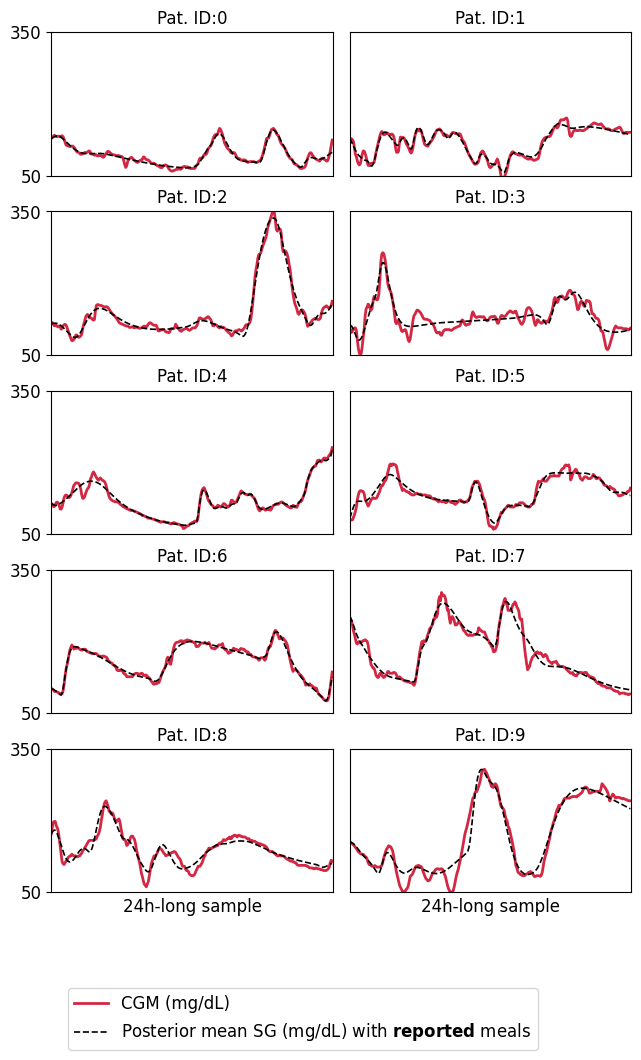

In [39]:
matplotlib.rcParams.update({'font.size': 12})
fig,axs = plt.subplots(5,2,figsize=[8,12])
time_ax = np.arange(288,)/12.0
patients = [0,1,2,3,4,5,6,7,8,9]
bg = np.array(full_extract[0]["bg"])
sample_idx = 12
for i in range(5,):
    for j in range(2,):
        r_idx = i*2+j
        patidx = patients[r_idx]
        all_post_pred = cohort_predictions[patidx]
        posteriors = cohort_posteriors[patidx]
        cgm_plot, = axs[i,j].plot(time_ax,dataset["samples"][0,patidx,sample_idx,:],color=[0.831, 0.153, 0.263],linewidth=2)
        announced_plot, = axs[i,j].plot(time_ax,all_post_pred["y_pred"][:,sample_idx,:].mean(0),color=[0,0,0],linestyle="--",linewidth=1.2)
        pi = np.percentile(all_post_pred["y_pred"][:,sample_idx,:], [10.0, 90.0], 0)
        og_position = axs[i,j].get_position()
        axs[i,j].set_position([og_position.x0-0.05-j*0.05,og_position.y0+0.1+i*0.01,og_position.width*1,og_position.height*0.9])
        axs[i,j].set_title("Pat. ID:"+str(patidx),{'fontsize':12} )
        axs[i,j].set_xlim([0,24])
        axs[i,j].set_ylim([50,350])
        if j==0:
            axs[i,j].set_yticks([50,350],labels=[50,350])
        else:
            axs[i,j].set_yticks([])
        axs[i,j].set_xticks([])
        if i==4:
            axs[i,j].set_xlabel("24h-long sample")
axs[-1,-1].legend([cgm_plot,announced_plot],["CGM (mg/dL)",r"Posterior mean SG (mg/dL) with $\bf{reported}$ meals"],loc=(-1.0,-1.1))

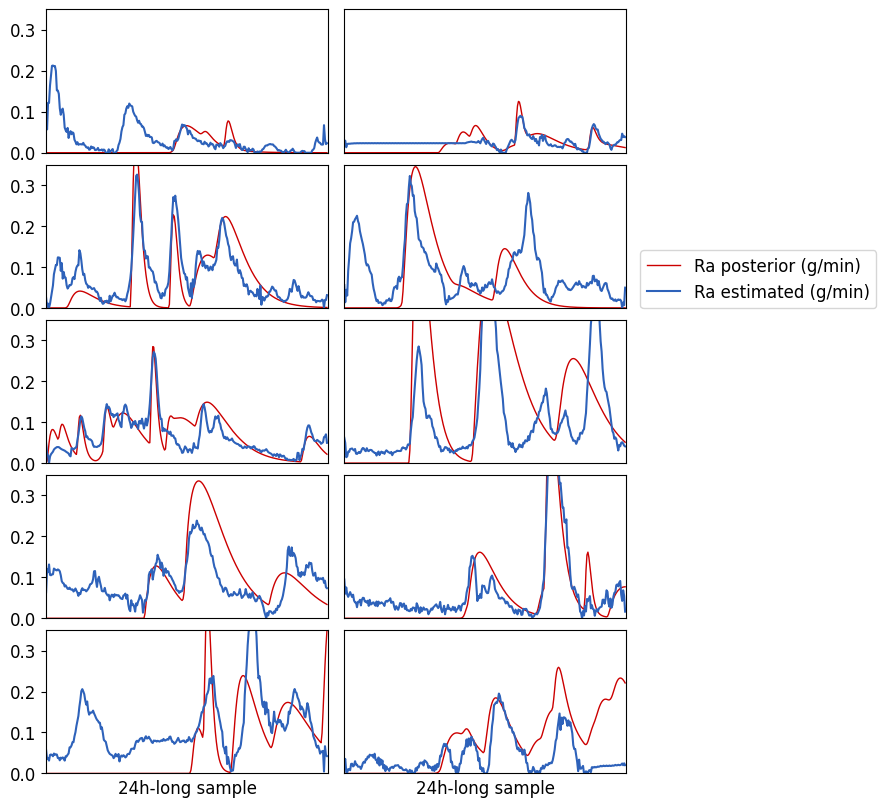

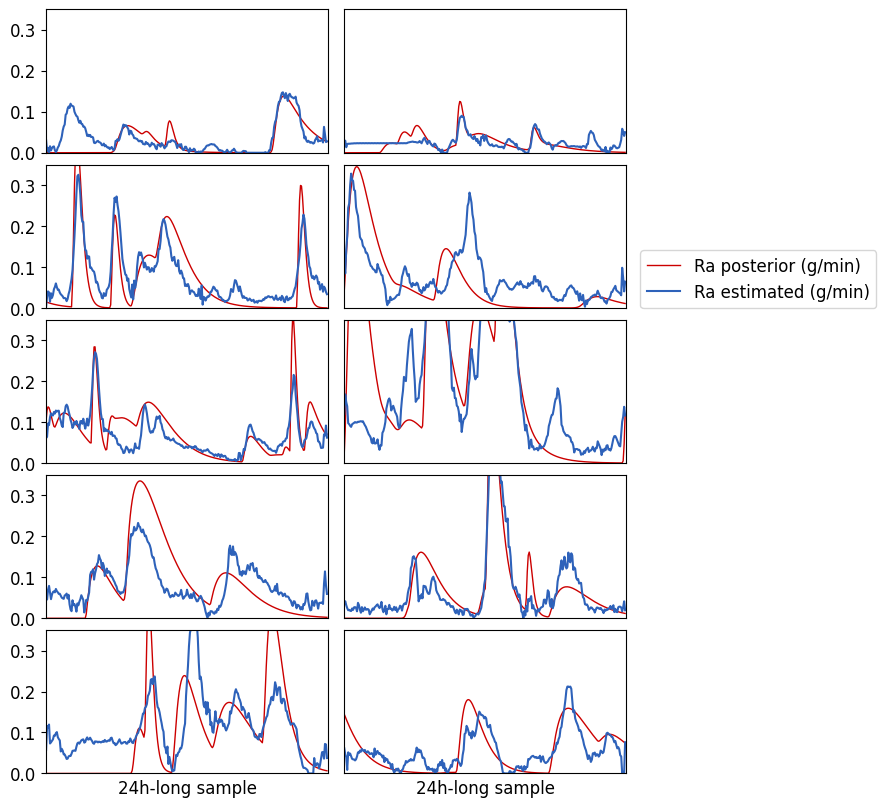

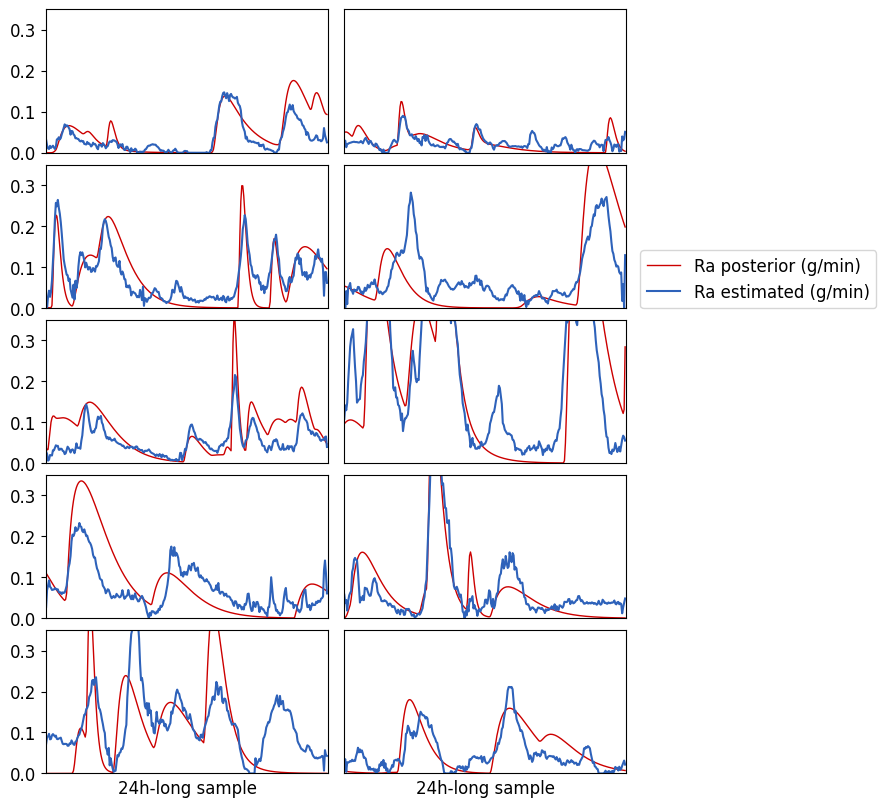

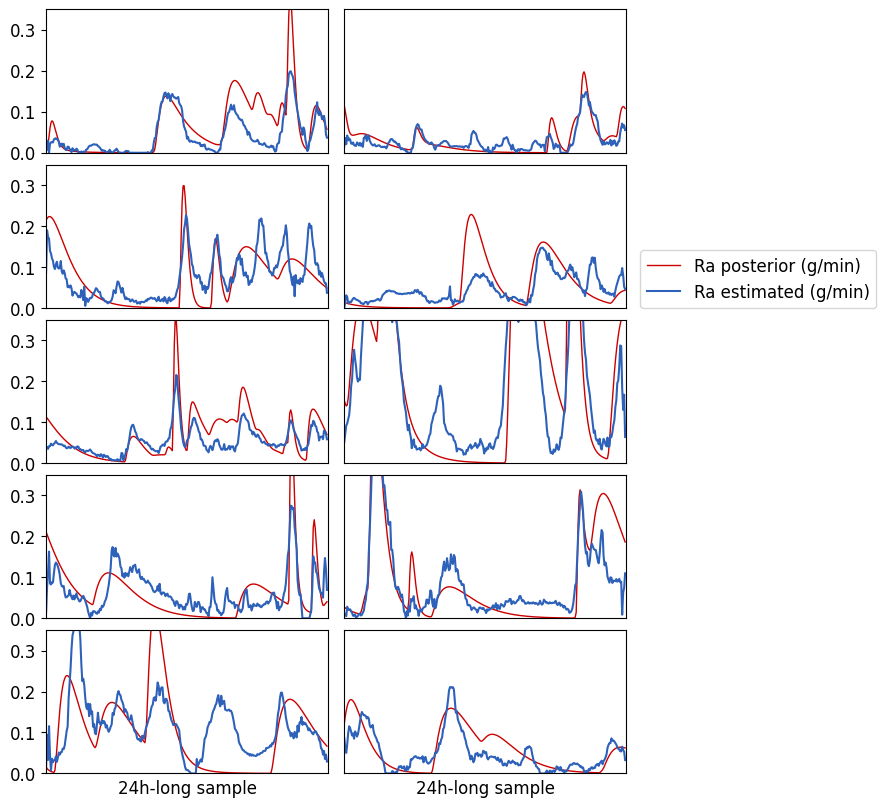

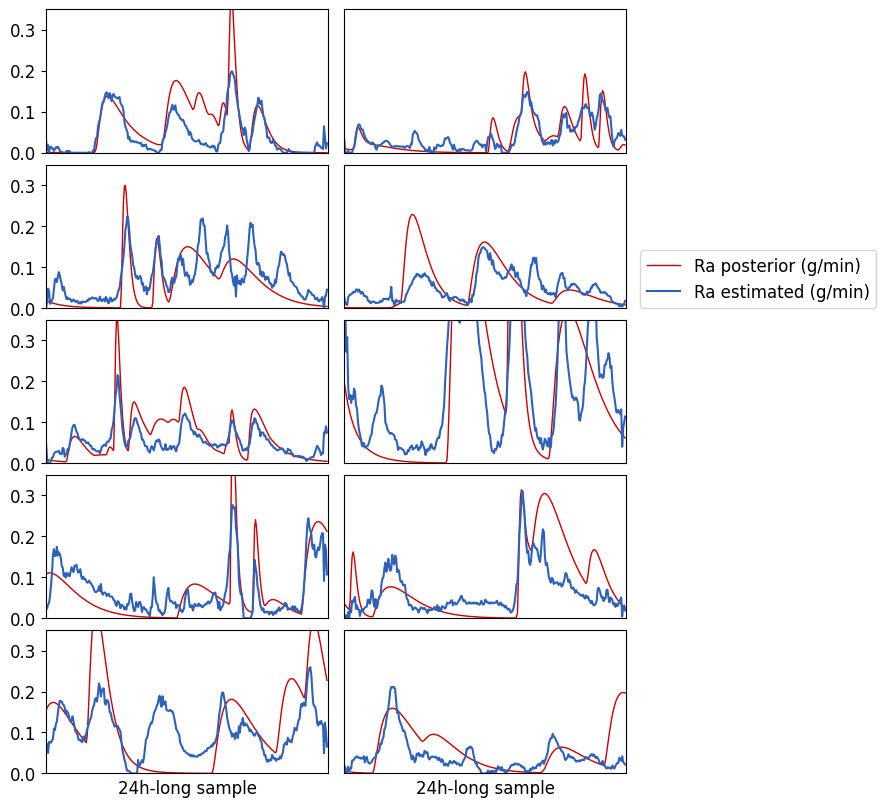

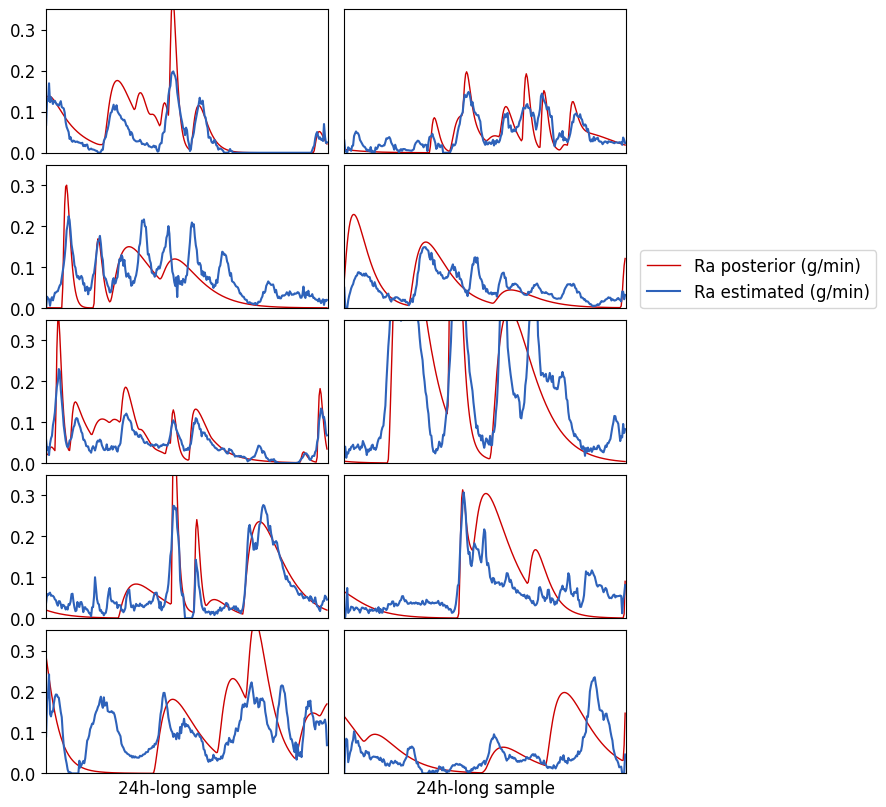

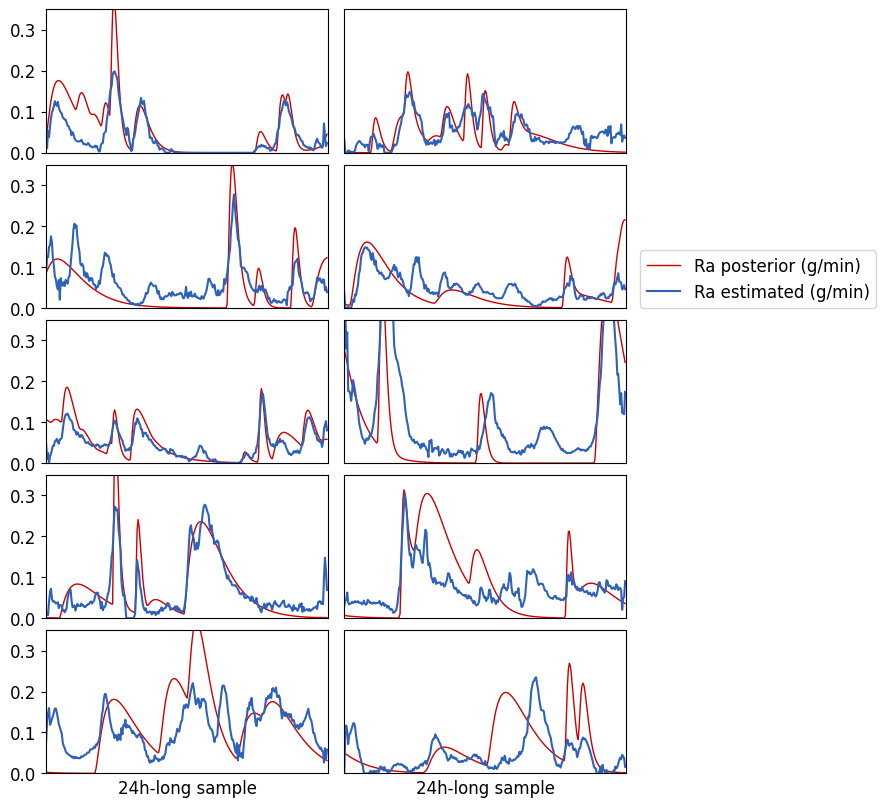

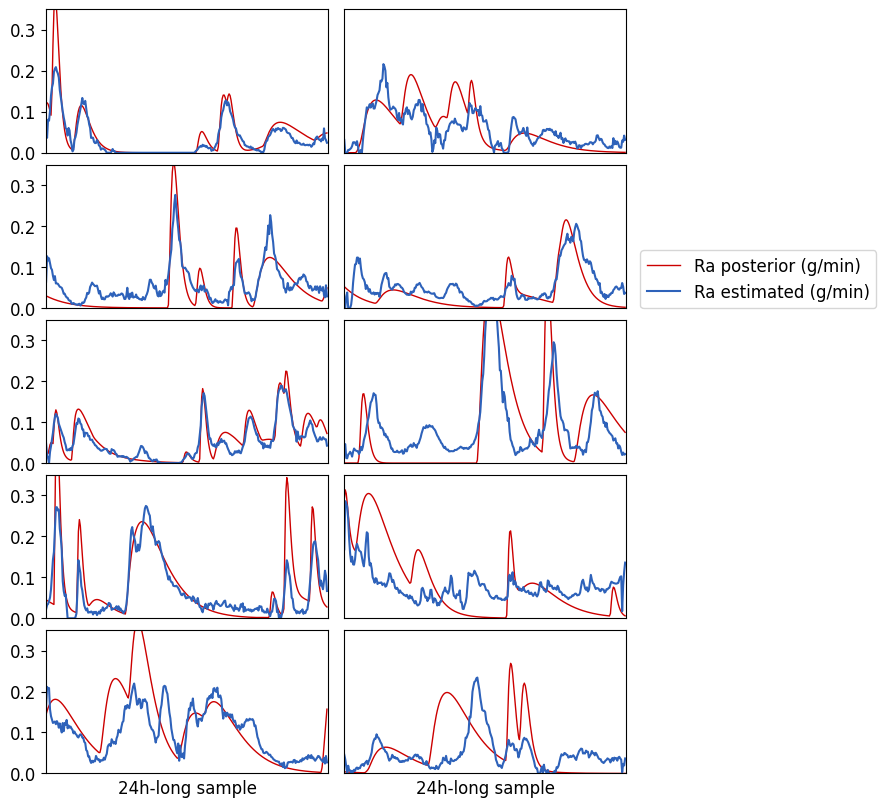

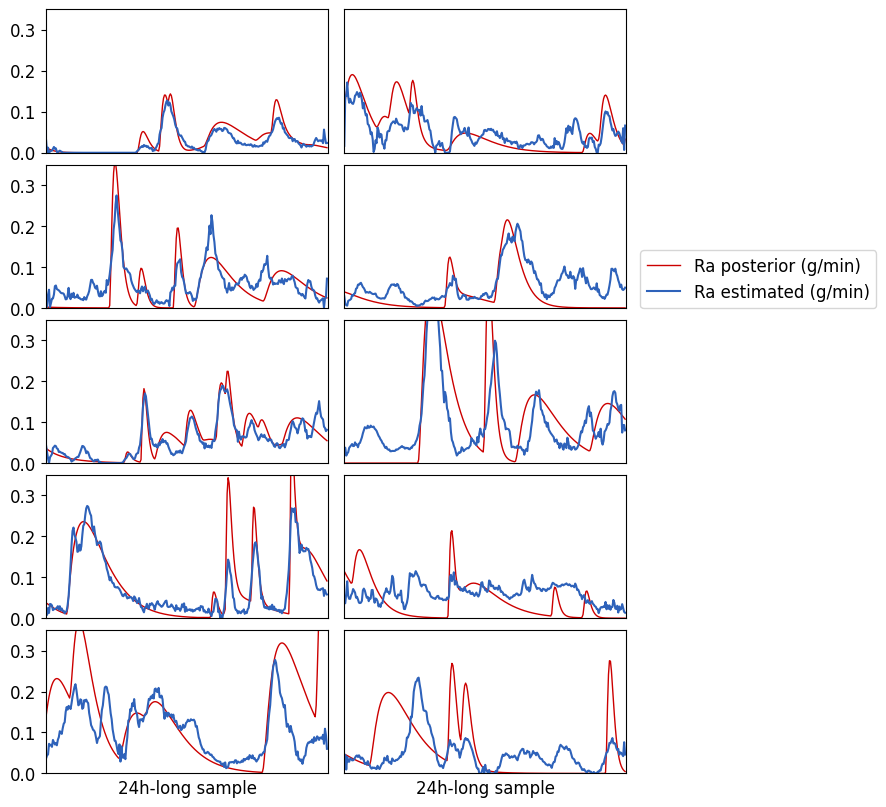

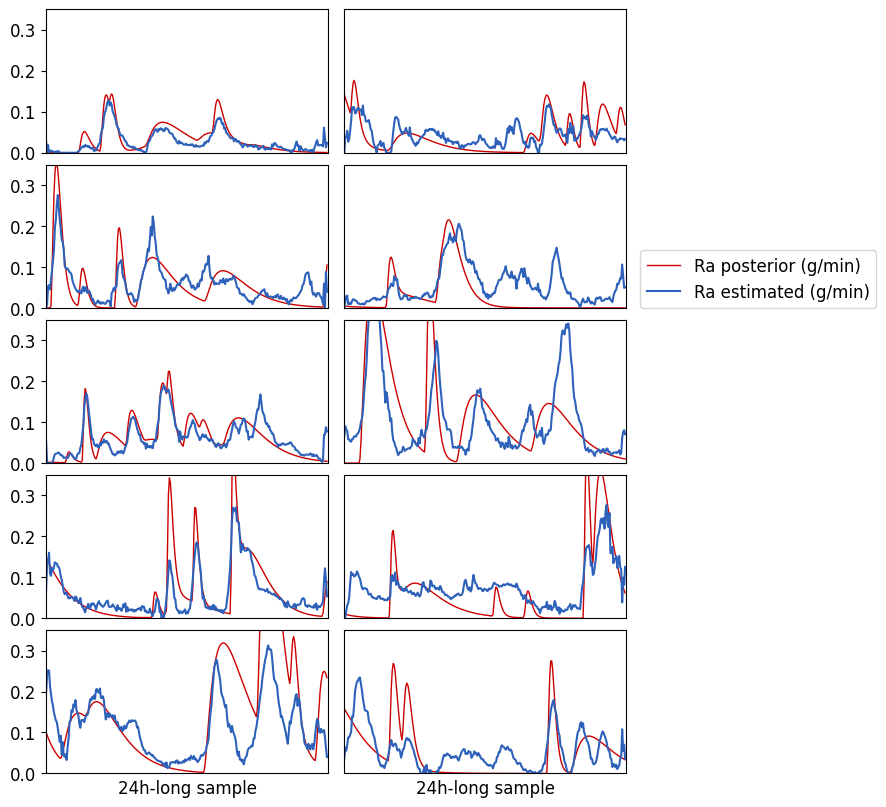

In [40]:
matplotlib.rcParams.update({'font.size': 12})
time_ax = np.arange(288,)/12.0
patients = range(10,)
for sample_idx in range(10,):
    fig,axs = plt.subplots(5,2,figsize=[8,12])
    for i in range(5,):
        for j in range(2,):
            r_idx = i*2+j
            patidx = patients[r_idx]
            all_post_pred = cohort_predictions[patidx]
            posteriors = cohort_posteriors[patidx]
            mu_Ra = jnp.mean(all_post_pred["Ra_pred"][:,sample_idx,:], 0)
            ra_plot, = axs[i,j].plot(time_ax, mu_Ra,color=[0.8,0,0], linestyle="-", lw=1)
            mu_Pa = jnp.mean(all_post_pred["Ra_est"][:,sample_idx,:], 0)
            Pa_plot, = axs[i,j].plot(time_ax, mu_Pa, color=[0.18, 0.384, 0.729], linestyle="-", lw=1.5)
            og_position = axs[i,j].get_position()
            axs[i,j].set_position([og_position.x0-0.05-j*0.05,og_position.y0+i*0.03,og_position.width*1,og_position.height*0.9])
            axs[i,j].set_xlim([0,24])
            axs[i,j].set_ylim([0,0.35])
            if j==1:
                axs[i,j].set_yticks([])
            axs[i,j].set_xticks([])
            if i==4:
                axs[i,j].set_xlabel("24h-long sample")
    lege = axs[1,1].legend(["Ra posterior (g/min)","Ra estimated (g/min)"],loc=(1.05,0))
#plt.savefig("ifac_wc/ra_est2.svg")